# Analyse des taux d'acceptation des demandes d'asile africaines en Europe
### HCR — Bureau Europe | 2015–2023

**Problématique :** Pourquoi les taux d'acceptation des demandes d'asile africaines varient-ils entre les pays européens ?

**Hypothèses :**
- H1 : les pays qui reçoivent beaucoup de demandes ont des taux plus faibles
- H2 : les demandeurs venant de pays en crise obtiennent des taux plus élevés
- H3 : les taux varient selon les périodes de pression migratoire
- H4 : les pays européens plus riches acceptent plus de demandes

## 1. Imports

In [1]:
import zipfile
import gzip
import os
import sqlite3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from matplotlib.patches import Patch

DATA   = './data'
OUTPUT = './output'
os.makedirs(OUTPUT, exist_ok=True)

print('Imports OK')

Imports OK


## 2. Paramètres — pays et période

In [2]:
# Période d'analyse
ANNEE_DEBUT = 2015
ANNEE_FIN   = 2023

# Pays européens d'accueil (ISO-3, format HCR)
PAYS_EU = [
    'AUT','BEL','BGR','CYP','CZE','DEU','DNK','EST','ESP','FIN','FRA',
    'GRC','HRV','HUN','IRL','ITA','LVA','LTU','LUX','MLT','NLD','POL',
    'PRT','ROU','SVK','SVN','SWE','NOR','CHE'
]

# Correspondance ISO-3 (HCR) → ISO-2 (Eurostat)
# Attention : la Grèce est codée EL dans Eurostat, pas GR
ISO3_ISO2 = {
    'AUT':'AT','BEL':'BE','BGR':'BG','CYP':'CY','CZE':'CZ','DEU':'DE',
    'DNK':'DK','EST':'EE','ESP':'ES','FIN':'FI','FRA':'FR','GRC':'EL',
    'HRV':'HR','HUN':'HU','IRL':'IE','ITA':'IT','LVA':'LV','LTU':'LT',
    'LUX':'LU','MLT':'MT','NLD':'NL','POL':'PL','PRT':'PT','ROU':'RO',
    'SVK':'SK','SVN':'SI','SWE':'SE','NOR':'NO','CHE':'CH'
}
EU_ISO2 = list(ISO3_ISO2.values())

# Pays africains d'origine (ISO-3)
PAYS_AFR = [
    'DZA','AGO','BEN','BWA','BFA','BDI','CMR','CPV','CAF','TCD',
    'COM','COD','COG','DJI','EGY','GNQ','ERI','ETH','SWZ','GAB',
    'GMB','GHA','GIN','GNB','CIV','KEN','LSO','LBR','LBY','MDG',
    'MWI','MLI','MRT','MUS','MAR','MOZ','NAM','NER','NGA','RWA',
    'STP','SEN','SLE','SOM','ZAF','SSD','SDN','TZA','TGO','TUN',
    'UGA','ZMB','ZWE','ESH'
]

print(f'{len(PAYS_EU)} pays d\'accueil | {len(PAYS_AFR)} pays d\'origine | {ANNEE_DEBUT}–{ANNEE_FIN}')

29 pays d'accueil | 54 pays d'origine | 2015–2023


## 3. Chargement des données brutes

In [3]:
# Les fichiers HCR sont dans des archives ZIP
# Les fichiers Eurostat sont compressés en GZ
# On les lit directement sans extraire

with zipfile.ZipFile(f'{DATA}/HCR_decision_d_asile.zip') as z:
    with z.open('asylum_decisions.csv') as f:
        df_dec_brut = pd.read_csv(f)

with zipfile.ZipFile(f'{DATA}/HCR_demande__d_asile.zip') as z:
    with z.open('asylum_applications.csv') as f:
        df_app_brut = pd.read_csv(f)

with zipfile.ZipFile(f'{DATA}/HCR_chiffre_population.zip') as z:
    with z.open('persons_of_concern.csv') as f:
        df_pop_brut = pd.read_csv(f)

with gzip.open(f'{DATA}/Eurostat_PIB_par_Habitant_UE.gz', 'rt', encoding='utf-8') as f:
    df_pib_brut = pd.read_csv(f)

with gzip.open(f'{DATA}/Eurostat_PIB_UE.gz', 'rt', encoding='utf-8') as f:
    df_pibt_brut = pd.read_csv(f)

df_emdat_brut = pd.read_excel(f'{DATA}/emdat.xlsx', sheet_name='EM-DAT Data')

print('Fichiers chargés :')
for nom, d in [('Décisions',df_dec_brut),('Demandes',df_app_brut),('Population',df_pop_brut),
               ('PIB/hab',df_pib_brut),('PIB total',df_pibt_brut),('EM-DAT',df_emdat_brut)]:
    print(f'  {nom:<12} : {d.shape[0]:>7,} lignes × {d.shape[1]} colonnes')

Fichiers chargés :
  Décisions    : 112,498 lignes × 13 colonnes
  Demandes     : 119,139 lignes × 10 colonnes
  Population   : 138,225 lignes × 12 colonnes
  PIB/hab      :  31,303 lignes × 19 colonnes
  PIB total    :   4,151 lignes × 19 colonnes
  EM-DAT       :  16,692 lignes × 47 colonnes


## 4. Exploration

In [4]:
# Aperçu du fichier principal
print('Colonnes :', list(df_dec_brut.columns))
print()
df_dec_brut.head(3)

Colonnes : ['Year', 'Country of Asylum', 'Country of Origin', 'Country of Asylum ISO', 'Country of Origin ISO', 'Procedure Type', 'Dec level', 'Dec pc', 'Dec recognized', 'dec other', 'dec rejected', 'dec closed', 'dec total']



,Year,Country of Asylum,Country of Origin,Country of Asylum ISO,Country of Origin ISO,Procedure Type,Dec level,Dec pc,Dec recognized,dec other,dec rejected,dec closed,dec total
0,2000,Australia,Afghanistan,AUS,AFG,G,AR,C,38,0,25,0,63
1,2000,Australia,Albania,AUS,ALB,G,AR,C,5,0,24,0,29
2,2000,Australia,Algeria,AUS,DZA,G,AR,C,5,0,17,0,22


In [5]:
# Valeurs manquantes
print('Valeurs manquantes — Décisions :')
print(df_dec_brut.isnull().sum())
print()
print('Procedure Type :', df_dec_brut['Procedure Type'].value_counts().to_dict())
print('Dec level      :', df_dec_brut['Dec level'].value_counts().to_dict())
# FI = première instance | G = procédure générale — ce sont les données qu'on gardera

Valeurs manquantes — Décisions :
Year                        0
Country of Asylum           0
Country of Origin           0
Country of Asylum ISO       0
Country of Origin ISO       0
Procedure Type              0
Dec level                2138
Dec pc                      0
Dec recognized              0
dec other                   0
dec rejected                0
dec closed                  0
dec total                   0
dtype: int64

Procedure Type : {'G': 98324, 'U': 13507, 'J': 667}
Dec level      : {'FI': 64754, 'AR': 19996, 'FA': 8844, 'RA': 5490, 'JR': 3500, 'IN': 3334, 'EO': 3243, 'TA': 540, 'SP': 303, 'CA': 177, 'BL': 95, 'TP': 83, 'TR': 1}


In [6]:
# Unités disponibles dans Eurostat
print('Unités PIB/hab disponibles :')
print(df_pib_brut[['unit','Unit of measure']].drop_duplicates().to_string(index=False))
# On gardera CP_EUR_HAB = euros courants par habitant

Unités PIB/hab disponibles :
                    unit                                                                                                               Unit of measure
              CP_EUR_HAB                                                                                               Current prices, euro per capita
              CP_NAC_HAB                                                                         Current prices, units of national currency per capita
    CP_PPS_EU27_2020_HAB                                                    Current prices, purchasing power standard (PPS, EU27 from 2020) per capita
PC_EU27_2020_HAB_MEUR_CP                       Percentage of EU27 (from 2020) total per capita (based on million euro, EU27 from 2020), current prices
PC_EU27_2020_HAB_MPPS_CP Percentage of EU27 (from 2020) total per capita (based on million purchasing power standards, EU27 from 2020), current prices


## 5. Nettoyage

In [7]:
# Décisions d'asile 
# Filtres : période, pays EU, pays africains, première instance, procédure générale
# On exclut dec_total = 0 pour éviter une division par zéro

dec = df_dec_brut.copy()
dec = dec[
    dec['Year'].between(ANNEE_DEBUT, ANNEE_FIN) &
    dec['Country of Asylum ISO'].isin(PAYS_EU) &
    dec['Country of Origin ISO'].isin(PAYS_AFR) &
    (dec['Dec level'] == 'FI') &
    (dec['Procedure Type'] == 'G') &
    (dec['dec total'] > 0)
]

dec = dec.rename(columns={
    'Year': 'annee',
    'Country of Asylum': 'pays_accueil',
    'Country of Origin': 'pays_origine',
    'Country of Asylum ISO': 'iso3_accueil',
    'Country of Origin ISO': 'iso3_origine',
    'Dec recognized': 'dec_pos',
    'dec rejected': 'dec_rej',
    'dec total': 'dec_total'
})

dec['iso2_accueil'] = dec['iso3_accueil'].map(ISO3_ISO2)
dec['taux']         = (dec['dec_pos'] / dec['dec_total'] * 100).round(2)
dec['pays_accueil'] = dec['pays_accueil'].str.replace(
    'Netherlands (Kingdom of the)', 'Netherlands', regex=False
)

dec = dec[['annee','pays_accueil','iso3_accueil','iso2_accueil',
           'pays_origine','iso3_origine','dec_pos','dec_rej','dec_total','taux']].reset_index(drop=True)

print(f'Décisions : {dec.shape[0]:,} lignes | NaN : {dec.isnull().sum().sum()}')

Décisions : 4,867 lignes | NaN : 0


In [8]:
#  Demandes d'asile 
# On garde uniquement les premières demandes (type A)
# On agrège pour supprimer les doublons liés aux niveaux de décision

app = df_app_brut.copy()
app = app[
    app['Year'].between(ANNEE_DEBUT, ANNEE_FIN) &
    app['Country of Asylum ISO'].isin(PAYS_EU) &
    app['Country of Origin ISO'].isin(PAYS_AFR) &
    (app['Application type'] == 'A')
]
app = app.groupby(
    ['Year','Country of Asylum ISO','Country of Origin ISO'], as_index=False
)['Applied'].sum()
app.columns = ['annee','iso3_accueil','iso3_origine','nb_demandes']

print(f'Demandes  : {app.shape[0]:,} lignes')

# PIB par habitant (Eurostat) 
# Unité CP_EUR_HAB = euros courants par habitant, indicateur B1GQ = PIB total

pib = df_pib_brut.copy()
pib = pib[
    (pib['unit'] == 'CP_EUR_HAB') & (pib['na_item'] == 'B1GQ') &
    pib['geo'].isin(EU_ISO2) & pib['TIME_PERIOD'].between(ANNEE_DEBUT, ANNEE_FIN)
]
pib = pib[['geo','TIME_PERIOD','OBS_VALUE']].rename(
    columns={'geo':'iso2_accueil','TIME_PERIOD':'annee','OBS_VALUE':'pib_hab'}
)
print(f'PIB/hab   : {pib.shape[0]:,} lignes | NaN : {pib.isnull().sum().sum()}')

# EM-DAT catastrophes Afrique 
# On filtre sur l'Afrique, la période et les pays de notre scope
# On agrège par pays × année pour avoir un indicateur de crise annuel

emdat = df_emdat_brut.copy()
emdat = emdat[
    (emdat['Region'] == 'Africa') &
    emdat['Start Year'].between(ANNEE_DEBUT, ANNEE_FIN) &
    emdat['ISO'].isin(PAYS_AFR)
]
emdat = emdat[['ISO','Start Year','Disaster Type','Total Deaths','Total Affected']].copy()
emdat.columns = ['iso3_origine','annee','type_cat','deces','affect']
emdat['deces']  = emdat['deces'].fillna(0)
emdat['affect'] = emdat['affect'].fillna(0)
emdat = emdat.groupby(['annee','iso3_origine'], as_index=False).agg(
    nb_cat = ('type_cat', 'count'),
    deces  = ('deces',    'sum'),
    affect = ('affect',   'sum')
)
print(f'EM-DAT    : {emdat.shape[0]:,} lignes')

Demandes  : 1,871 lignes
PIB/hab   : 261 lignes | NaN : 0
EM-DAT    : 373 lignes


## 6. SQL — requêtes de préparation et d'agrégation

In [9]:
# Chargement des tables dans SQLite
conn = sqlite3.connect(f'{OUTPUT}/hcr.db')
dec.to_sql('decisions', conn, if_exists='replace', index=False)
app.to_sql('demandes',  conn, if_exists='replace', index=False)
pib.to_sql('pib',       conn, if_exists='replace', index=False)
emdat.to_sql('crises',  conn, if_exists='replace', index=False)
print('Tables :', pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)['name'].tolist())

Tables : ['dataset_final', 'decisions', 'demandes', 'pib', 'crises']


In [10]:
# Taux moyen par pays d'accueil sur toute la période
res_taux = pd.read_sql("""
    SELECT pays_accueil,
           SUM(dec_pos)   AS positives,
           SUM(dec_total) AS total,
           ROUND(SUM(dec_pos) * 100.0 / SUM(dec_total), 2) AS taux_pct
    FROM decisions
    GROUP BY pays_accueil
    ORDER BY taux_pct DESC
""", conn)
print(res_taux.to_string(index=False))

pays_accueil  positives  total  taux_pct
      Norway       7801  12746     61.20
     Denmark       4885   8394     58.20
  Luxembourg       2225   3987     55.81
     Belgium      21498  47444     45.31
 Netherlands      13971  35270     39.61
      Sweden      19444  51069     38.07
     Finland       3102   9263     33.49
 Switzerland      23441  90630     25.86
     Germany      16680  65270     25.56
      Greece      14373  57036     25.20
     Ireland       3566  14893     23.94
      France      78599 377622     20.81
     Estonia         24    127     18.90
     Romania        787   4246     18.54
      Cyprus        342   2471     13.84
       Spain       5104  53377      9.56
    Portugal        420   4844      8.67
   Lithuania         26    366      7.10
       Italy      24962 370135      6.74
      Poland        110   1759      6.25
     Croatia         80   1591      5.03
       Malta        566  11956      4.73
     Hungary         45    979      4.60
     Czechia    

In [11]:
# Évolution du taux par année
res_annuel = pd.read_sql("""
    SELECT annee,
           SUM(dec_total) AS nb_decisions,
           ROUND(SUM(dec_pos) * 100.0 / SUM(dec_total), 2) AS taux_pct
    FROM decisions
    GROUP BY annee ORDER BY annee
""", conn)
print(res_annuel.to_string(index=False))

 annee  nb_decisions  taux_pct
  2015        127008     24.28
  2016        146122     18.04
  2017        143037     16.86
  2018        139522     16.05
  2019        126028     17.76
  2020         94245     20.41
  2021        147054     20.15
  2022        154147     21.04
  2023        162790     21.36


In [12]:
# Jointure décisions + PIB (pour H4)
res_pib = pd.read_sql("""
    SELECT d.pays_accueil,
           ROUND(SUM(d.dec_pos) * 100.0 / SUM(d.dec_total), 2) AS taux_pct,
           ROUND(AVG(p.pib_hab), 0) AS pib_moyen
    FROM decisions d
    LEFT JOIN pib p ON d.iso2_accueil = p.iso2_accueil AND d.annee = p.annee
    WHERE p.pib_hab IS NOT NULL
    GROUP BY d.pays_accueil
    ORDER BY pib_moyen DESC
""", conn)
print(res_pib.to_string(index=False))

pays_accueil  taux_pct  pib_moyen
  Luxembourg     55.81   104929.0
 Switzerland     25.86    80267.0
     Ireland     23.94    78009.0
      Norway     61.20    72456.0
     Denmark     58.20    54229.0
 Netherlands     39.61    48350.0
     Germany     25.56    48013.0
      Sweden     38.07    47789.0
     Finland     33.49    42740.0
     Belgium     45.31    42199.0
      France     20.81    36048.0
       Italy      6.74    30372.0
       Malta      4.73    29790.0
       Spain      9.56    26310.0
    Slovenia      0.73    24606.0
      Cyprus     13.84    24095.0
   Lithuania      7.10    23791.0
     Czechia      3.74    21786.0
    Portugal      8.67    20505.0
     Estonia     18.90    19679.0
    Slovakia      0.00    18439.0
      Latvia      0.00    17890.0
      Greece     25.20    17451.0
      Poland      6.25    15338.0
     Croatia      5.03    14761.0
     Hungary      4.60    14143.0
     Romania     18.54    11825.0
    Bulgaria      1.38     6696.0


In [13]:
# Jointure décisions + crises africaines (pour H2)
res_crises = pd.read_sql("""
    SELECT d.pays_origine,
           ROUND(SUM(d.dec_pos) * 100.0 / SUM(d.dec_total), 2) AS taux_pct,
           SUM(d.dec_total) AS nb_decisions,
           ROUND(AVG(COALESCE(c.nb_cat, 0)), 1) AS moy_catastrophes
    FROM decisions d
    LEFT JOIN crises c ON d.iso3_origine = c.iso3_origine AND d.annee = c.annee
    GROUP BY d.pays_origine
    HAVING SUM(d.dec_total) > 500
    ORDER BY taux_pct DESC
    LIMIT 12
""", conn)
print(res_crises.to_string(index=False))

          pays_origine  taux_pct  nb_decisions  moy_catastrophes
               Eritrea     66.79        126203               0.1
               Burundi     57.78          9556               2.1
                 Sudan     41.28         47768               2.8
  Central African Rep.     41.19          7240               1.9
           South Sudan     39.67          1205               2.0
                Rwanda     36.10          5410               2.7
                Uganda     35.91          3222               5.3
              Ethiopia     33.40         22274               3.1
              Djibouti     33.07          2250               0.9
               Somalia     32.20         88068               3.2
              Zimbabwe     22.03          2991               2.8
Dem. Rep. of the Congo     19.41         62426              11.2


In [14]:
pd.read_sql("PRAGMA table_info(demandes);", conn)


,cid,name,type,notnull,dflt_value,pk
0,0,annee,INTEGER,0,None,0
1,1,iso3_accueil,TEXT,0,None,0
2,2,iso3_origine,TEXT,0,None,0
3,3,nb_demandes,INTEGER,0,None,0


In [15]:
# Volume de demandes vs taux par pays (pour H1)
res_volume = pd.read_sql("""
    SELECT a.iso3_accueil AS pays_accueil,
           SUM(a.nb_demandes) AS total_demandes,
           ROUND(SUM(d.dec_pos) * 100.0 / SUM(d.dec_total), 2) AS taux_pct
    FROM demandes a
    LEFT JOIN decisions d 
        ON a.annee = d.annee 
       AND a.iso3_accueil = d.iso3_accueil
    GROUP BY a.iso3_accueil
    HAVING SUM(d.dec_total) > 0
    ORDER BY total_demandes DESC
""", conn)

print(res_volume.to_string(index=False))


pays_accueil  total_demandes  taux_pct
         FRA         8047605     20.28
         SWE          827839     38.26
         GRC          682607     25.82
         DEU          525182     23.67
         ITA          477280     12.56
         BEL          347066     49.29
         IRL          216509     23.99
         NOR          185998     62.92
         MLT           44388      6.54
         DNK           35279     58.58
         CYP           23181     17.25
         POL            6447      6.04
         LUX            4708     49.03
         SVN            1029      0.48
         HRV             961      3.67
         CZE             468      4.42


## 7. Fusion — dataset final

In [16]:
# On part des décisions et on ajoute les autres variables une par une

df = dec.copy()

# Nombre de demandes déposées
df = df.merge(app[['annee','iso3_accueil','iso3_origine','nb_demandes']],
              on=['annee','iso3_accueil','iso3_origine'], how='left')
df['nb_demandes'] = df['nb_demandes'].fillna(0)

# PIB par habitant
df = df.merge(pib[['annee','iso2_accueil','pib_hab']], on=['annee','iso2_accueil'], how='left')

# Indicateurs de catastrophes
df = df.merge(emdat[['annee','iso3_origine','nb_cat','deces','affect']],
              on=['annee','iso3_origine'], how='left')
for col in ['nb_cat','deces','affect']:
    df[col] = df[col].fillna(0)

# Suppression des lignes sans PIB
df = df.dropna(subset=['pib_hab']).reset_index(drop=True)

print(f'Dataset final : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'Colonnes : {list(df.columns)}')
print(f'NaN restants : {df.isnull().sum().sum()}')

Dataset final : 4,867 lignes × 15 colonnes
Colonnes : ['annee', 'pays_accueil', 'iso3_accueil', 'iso2_accueil', 'pays_origine', 'iso3_origine', 'dec_pos', 'dec_rej', 'dec_total', 'taux', 'nb_demandes', 'pib_hab', 'nb_cat', 'deces', 'affect']
NaN restants : 0


In [17]:
# Statistiques descriptives
df[['taux','dec_total','nb_demandes','pib_hab','nb_cat']].describe().round(2)

,taux,dec_total,nb_demandes,pib_hab,nb_cat
count,4867.00,4867.00,4867.00,4867.00,4867.00
mean,15.97,254.77,58.26,42248.24,3.12
std,26.74,955.09,292.43,23835.56,3.08
min,0.00,5.00,0.00,6560.00,0.00
25%,0.00,5.00,0.00,24190.00,1.00
50%,0.00,21.00,0.00,37810.00,2.00
75%,21.51,110.00,9.00,51060.00,4.00
max,100.00,19868.00,4957.00,122970.00,20.00


## 8. Export

In [18]:
# Export CSV
df.to_csv(f'{OUTPUT}/dataset_final.csv', index=False)
dec.to_csv(f'{OUTPUT}/decisions_clean.csv', index=False)
app.to_csv(f'{OUTPUT}/demandes_clean.csv', index=False)
pib.to_csv(f'{OUTPUT}/pib_clean.csv', index=False)
emdat.to_csv(f'{OUTPUT}/crises_clean.csv', index=False)

# Export SQLite
df.to_sql('dataset_final', conn, if_exists='replace', index=False)
conn.commit()
conn.close()

print('Fichiers exportés :')
for f in sorted(os.listdir(OUTPUT)):
    print(f'  {f}')

Fichiers exportés :
  crises_clean.csv
  dataset_final.csv
  decisions_clean.csv
  demandes_clean.csv
  h1_volume_taux.png
  h2_crises_taux.png
  h3_evolution.png
  h4_pib_taux.png
  hcr.db
  pib_clean.csv
  viz1_taux_par_pays.png
  viz2_heatmap.png


---
## 9. Analyse descriptive et visualisations exploratoires

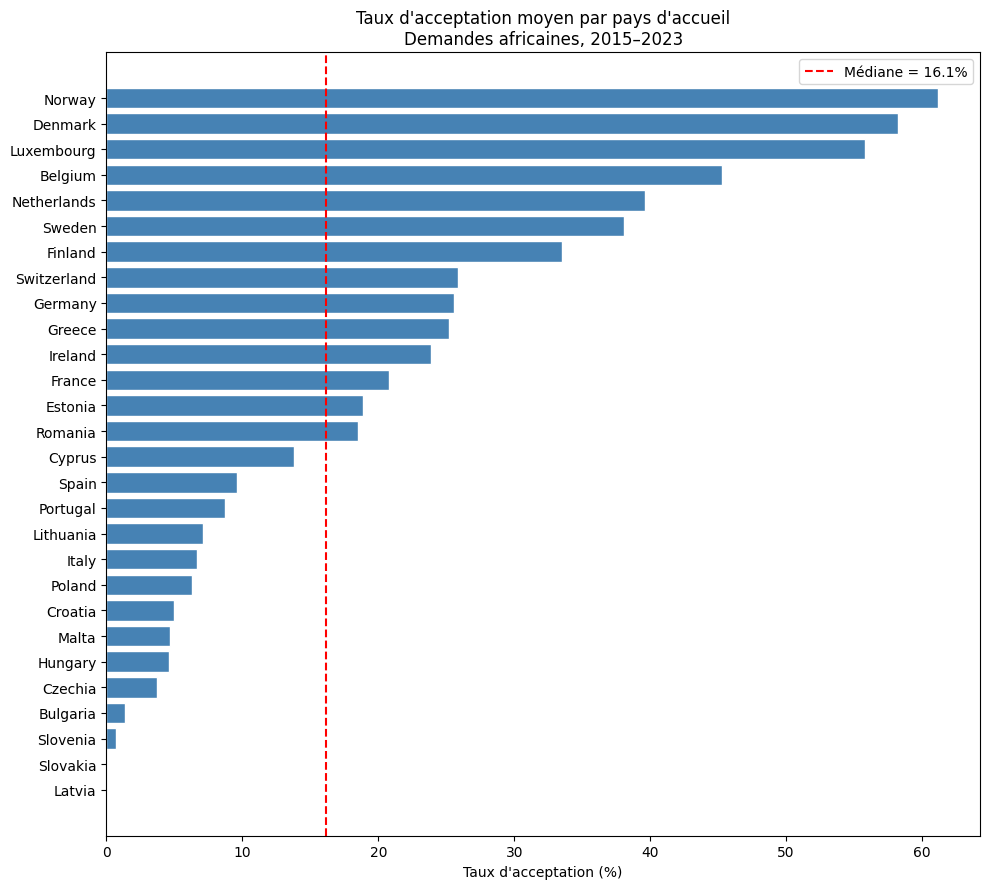

Taux le plus élevé : Norway (61.2%)
Taux le plus faible : Latvia (0.0%)
Médiane : 16.1%

Les disparités sont très importantes : la Norvège accepte 61% des demandes
alors que la Lettonie en accepte 0%. Ces écarts justifient toute l'analyse.


In [19]:
# Taux d'acceptation moyen par pays d'accueil (barplot horizontal)

taux_pays = (
    df.groupby('pays_accueil')
    .apply(lambda x: round(x['dec_pos'].sum() / x['dec_total'].sum() * 100, 1))
    .reset_index(name='taux_moyen')
    .sort_values('taux_moyen')
)

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(taux_pays['pays_accueil'], taux_pays['taux_moyen'], color='steelblue', edgecolor='white')
mediane = taux_pays['taux_moyen'].median()
ax.axvline(mediane, color='red', linestyle='--', linewidth=1.5, label=f'Médiane = {mediane:.1f}%')
ax.set_xlabel("Taux d'acceptation (%)")
ax.set_title("Taux d'acceptation moyen par pays d'accueil\nDemandes africaines, 2015–2023")
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT}/viz1_taux_par_pays.png', dpi=120)
plt.show()

print(f"Taux le plus élevé : {taux_pays['pays_accueil'].iloc[-1]} ({taux_pays['taux_moyen'].iloc[-1]}%)")
print(f"Taux le plus faible : {taux_pays['pays_accueil'].iloc[0]} ({taux_pays['taux_moyen'].iloc[0]}%)")
print(f"Médiane : {mediane:.1f}%")
print()
print("Les disparités sont très importantes : la Norvège accepte 61% des demandes")
print("alors que la Lettonie en accepte 0%. Ces écarts justifient toute l'analyse.")

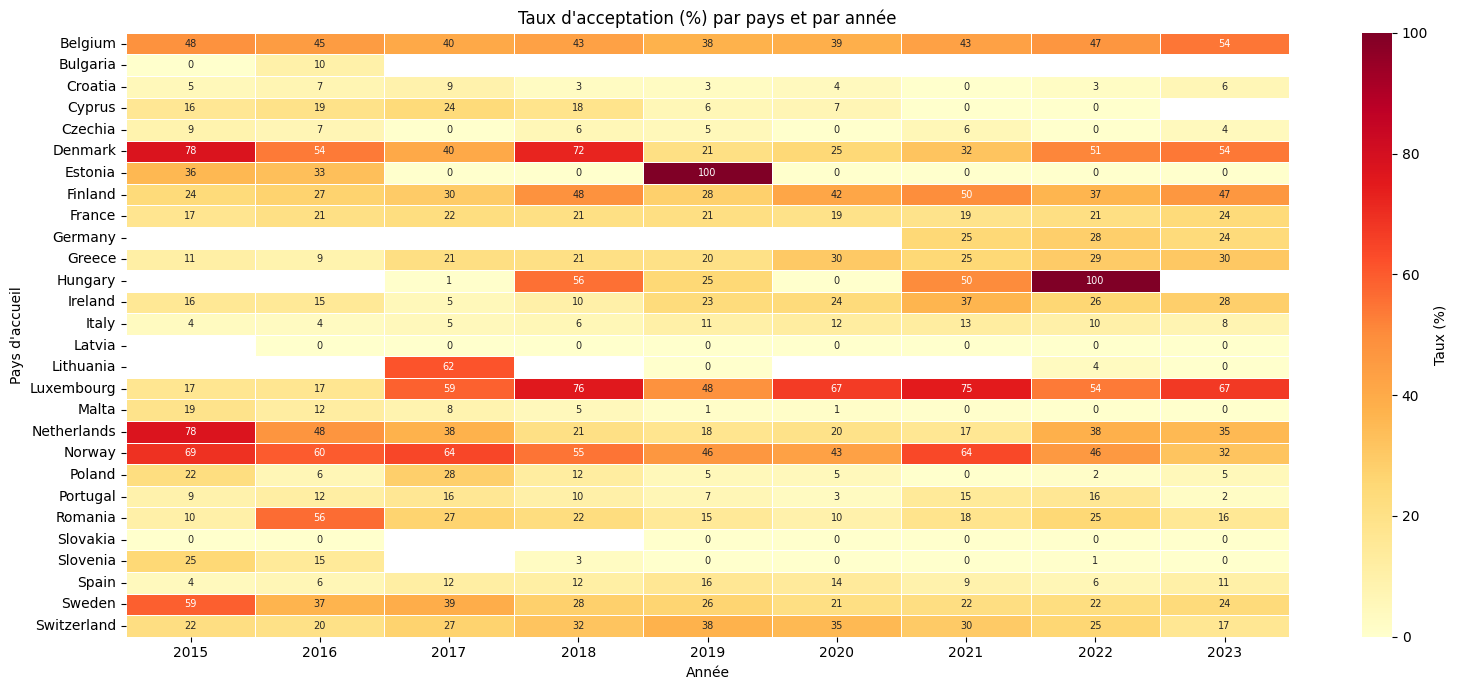

La heatmap confirme les disparités entre pays. On voit aussi une tendance
temporelle : les taux sont plus bas autour de 2016-2018 pour beaucoup de pays.


In [20]:
# Heatmap : taux d'acceptation par pays × année

pivot = (
    df.groupby(['annee','pays_accueil'])
    .apply(lambda x: round(x['dec_pos'].sum() / x['dec_total'].sum() * 100, 1))
    .unstack('pays_accueil')
)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(pivot.T, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.4, cbar_kws={'label': 'Taux (%)'}, annot_kws={'size': 7}, ax=ax)
ax.set_title("Taux d'acceptation (%) par pays et par année")
ax.set_xlabel('Année')
ax.set_ylabel("Pays d'accueil")
plt.tight_layout()
plt.savefig(f'{OUTPUT}/viz2_heatmap.png', dpi=120)
plt.show()

print("La heatmap confirme les disparités entre pays. On voit aussi une tendance")
print("temporelle : les taux sont plus bas autour de 2016-2018 pour beaucoup de pays.")

---
## 10. Test des hypothèses

Pour chaque hypothèse, on calcule une corrélation de Pearson.

**Rappel :**
- `r` = coefficient de corrélation entre -1 et +1 (0 = aucune relation)
- `p` = probabilité que le résultat soit dû au hasard (p < 0.05 = résultat fiable)

### H1 — Volume de demandes et taux d'acceptation

In [21]:
# On agrège par pays d'accueil × année
# pour avoir le total de demandes et le taux de chaque pays chaque année

h1 = (
    df.groupby(['annee', 'pays_accueil'])
    .apply(lambda x: pd.Series({
        'total_demandes': x['nb_demandes'].sum(),
        'taux': x['dec_pos'].sum() / x['dec_total'].sum() * 100
    }))
    .reset_index()
)

r1, p1 = pearsonr(h1['total_demandes'], h1['taux'])
print(f'r = {r1:.3f}  |  p = {p1:.4f}')

r = 0.022  |  p = 0.7392


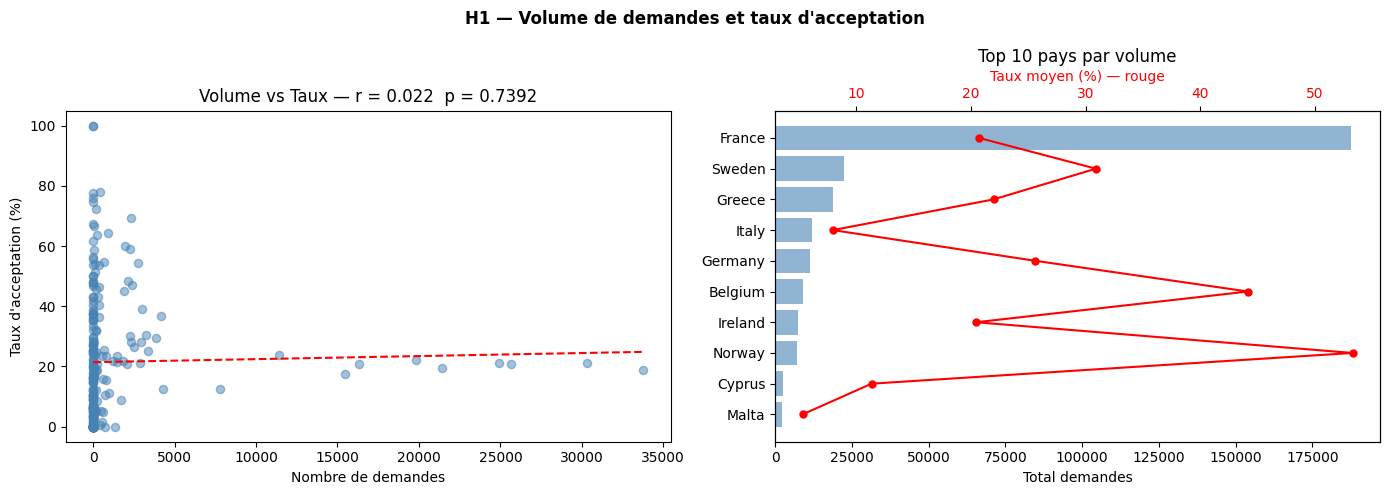

r = 0.022 → corrélation quasi nulle
p = 0.7392 → résultat non significatif

VERDICT H1 : INFIRMÉE
La France reçoit plus de 33 000 demandes en 2021 et affiche ~20%,
identique à des pays recevant 10 fois moins. Le volume ne joue pas.


In [22]:
# Visualisation H1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Nuage de points
axes[0].scatter(h1['total_demandes'], h1['taux'], alpha=0.5, color='steelblue', s=35)
z = np.polyfit(h1['total_demandes'], h1['taux'], 1)
x_r = np.linspace(h1['total_demandes'].min(), h1['total_demandes'].max(), 100)
axes[0].plot(x_r, np.poly1d(z)(x_r), 'r--', linewidth=1.5)
axes[0].set_xlabel('Nombre de demandes')
axes[0].set_ylabel("Taux d'acceptation (%)")
axes[0].set_title(f'Volume vs Taux — r = {r1:.3f}  p = {p1:.4f}')

# Top 10 pays par volume avec taux en surimpression
top10 = h1.groupby('pays_accueil').agg(
    total=('total_demandes','sum'), taux_moy=('taux','mean')
).nlargest(10,'total').sort_values('total')
axes[1].barh(top10.index, top10['total'], color='steelblue', alpha=0.6)
ax2 = axes[1].twiny()
ax2.plot(top10['taux_moy'], top10.index, 'ro-', markersize=5)
axes[1].set_xlabel('Total demandes')
ax2.set_xlabel("Taux moyen (%) — rouge", color='red')
ax2.tick_params(axis='x', labelcolor='red')
axes[1].set_title('Top 10 pays par volume')

plt.suptitle("H1 — Volume de demandes et taux d'acceptation", fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/h1_volume_taux.png', dpi=120)
plt.show()

print(f'r = {r1:.3f} → corrélation quasi nulle')
print(f'p = {p1:.4f} → résultat non significatif')
print()
print('VERDICT H1 : INFIRMÉE')
print('La France reçoit plus de 33 000 demandes en 2021 et affiche ~20%,')
print('identique à des pays recevant 10 fois moins. Le volume ne joue pas.')

### H2 — Pays d'origine en situation de crise

In [23]:
# On agrège par pays d'origine × année

h2 = (
    df.groupby(['annee', 'pays_origine'])
    .apply(lambda x: pd.Series({
        'taux':   x['dec_pos'].sum() / x['dec_total'].sum() * 100,
        'nb_cat': x['nb_cat'].iloc[0]
    }))
    .reset_index()
)

r2, p2 = pearsonr(h2['nb_cat'], h2['taux'])
print(f'r = {r2:.3f}  |  p = {p2:.4f}')

# Pays en crise vs pays stables
h2['en_crise'] = h2['nb_cat'] > 0
print(f"Taux moyen — pays en crise  : {h2[h2['en_crise']]['taux'].mean():.1f}%")
print(f"Taux moyen — pays stables   : {h2[~h2['en_crise']]['taux'].mean():.1f}%")

# Top pays africains
top_orig = (
    df.groupby('pays_origine')
    .apply(lambda x: pd.Series({
        'taux': round(x['dec_pos'].sum()/x['dec_total'].sum()*100,1),
        'n': int(x['dec_total'].sum()),
        'moy_cat': round(x['nb_cat'].mean(),1)
    })).reset_index()
)
top_orig = top_orig[top_orig['n']>500].sort_values('taux',ascending=False).head(12)
print()
print('Top 12 pays africains par taux :')
print(top_orig[['pays_origine','taux','moy_cat']].to_string(index=False))

r = -0.016  |  p = 0.7310
Taux moyen — pays en crise  : 16.3%
Taux moyen — pays stables   : 17.0%

Top 12 pays africains par taux :
          pays_origine  taux  moy_cat
               Eritrea  66.8      0.1
               Burundi  57.8      2.1
                 Sudan  41.3      2.8
  Central African Rep.  41.2      1.9
           South Sudan  39.7      2.0
                Rwanda  36.1      2.7
                Uganda  35.9      5.3
              Ethiopia  33.4      3.1
              Djibouti  33.1      0.9
               Somalia  32.2      3.2
              Zimbabwe  22.0      2.8
Dem. Rep. of the Congo  19.4     11.2


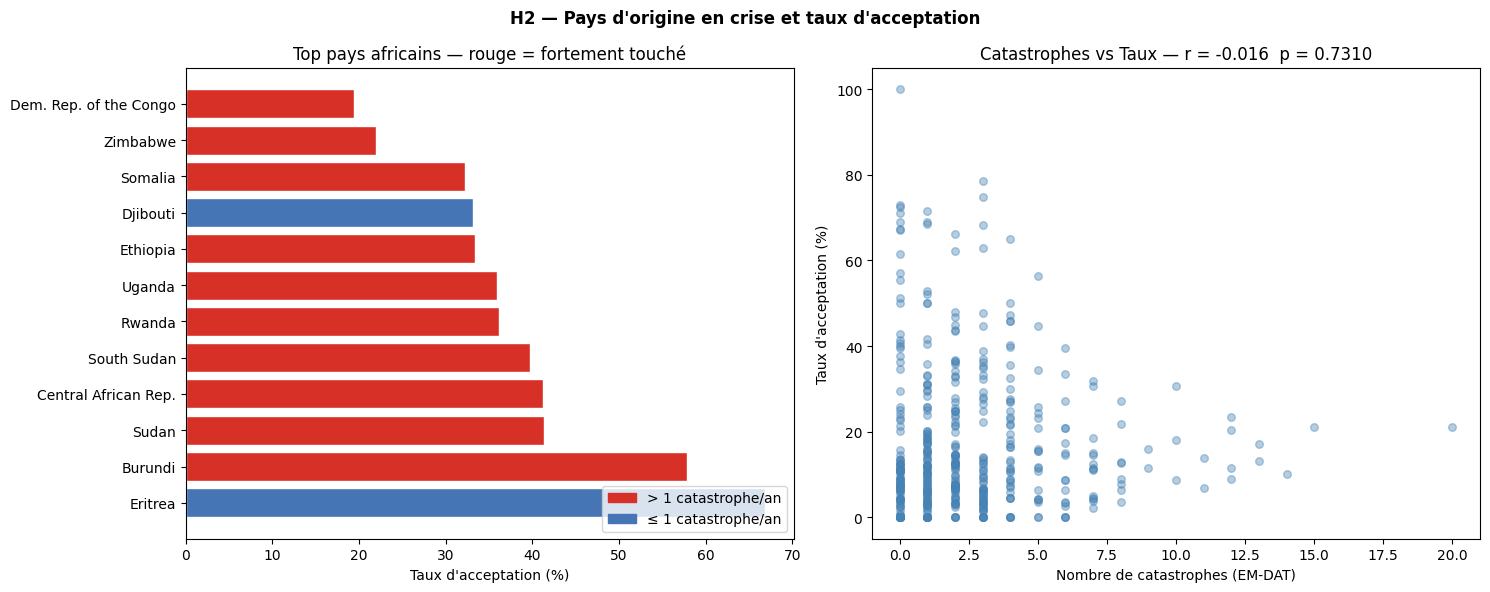

r = -0.016 → corrélation quasi nulle
p = 0.7310 → non significatif

VERDICT H2 : PARTIELLEMENT CONFIRMÉE
Les pays les plus affectés ont bien des taux élevés :
Érythrée 66.8%, Soudan 41.3%, Somalie 32.2%.
Mais la corrélation statistique est faible car EM-DAT ne couvre
pas les conflits armés, principale raison de fuite.


In [24]:
# Visualisation H2

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Barplot : rouge = >1 catastrophe/an, bleu = stable
couleurs = ['#d73027' if c > 1 else '#4575b4' for c in top_orig['moy_cat']]
axes[0].barh(top_orig['pays_origine'], top_orig['taux'], color=couleurs, edgecolor='white')
axes[0].legend(handles=[
    Patch(color='#d73027', label='> 1 catastrophe/an'),
    Patch(color='#4575b4', label='≤ 1 catastrophe/an')
], loc='lower right')
axes[0].set_xlabel("Taux d'acceptation (%)")
axes[0].set_title('Top pays africains — rouge = fortement touché')

# Scatter
axes[1].scatter(h2['nb_cat'], h2['taux'], alpha=0.4, color='steelblue', s=30)
axes[1].set_xlabel('Nombre de catastrophes (EM-DAT)')
axes[1].set_ylabel("Taux d'acceptation (%)")
axes[1].set_title(f'Catastrophes vs Taux — r = {r2:.3f}  p = {p2:.4f}')

plt.suptitle("H2 — Pays d'origine en crise et taux d'acceptation", fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/h2_crises_taux.png', dpi=120)
plt.show()

print(f'r = {r2:.3f} → corrélation quasi nulle')
print(f'p = {p2:.4f} → non significatif')
print()
print('VERDICT H2 : PARTIELLEMENT CONFIRMÉE')
print('Les pays les plus affectés ont bien des taux élevés :')
print('Érythrée 66.8%, Soudan 41.3%, Somalie 32.2%.')
print('Mais la corrélation statistique est faible car EM-DAT ne couvre')
print('pas les conflits armés, principale raison de fuite.')

### H3 — Effet temporel

In [25]:
# Taux annuel moyen + volume de décisions

h3 = (
    df.groupby('annee')
    .apply(lambda x: round(x['dec_pos'].sum() / x['dec_total'].sum() * 100, 2))
    .reset_index(name='taux')
)
vol = df.groupby('annee')['dec_total'].sum().reset_index(name='volume')
h3 = h3.merge(vol, on='annee')

print('Taux annuel moyen :')
print(h3.to_string(index=False))

# Périodes
df['periode'] = pd.cut(df['annee'], bins=[2014,2016,2019,2023],
    labels=['Pic (2015–2016)','Stabilisation (2017–2019)','Remontée (2020–2023)'])
taux_periode = (
    df.groupby('periode')
    .apply(lambda x: round(x['dec_pos'].sum()/x['dec_total'].sum()*100, 2))
    .reset_index(name='taux_moyen')
)
print()
print('Taux moyen par période :')
print(taux_periode.to_string(index=False))

Taux annuel moyen :
 annee  taux  volume
  2015 24.28  127008
  2016 18.04  146122
  2017 16.86  143037
  2018 16.05  139522
  2019 17.76  126028
  2020 20.41   94245
  2021 20.15  147054
  2022 21.04  154147
  2023 21.36  162790

Taux moyen par période :
                  periode  taux_moyen
          Pic (2015–2016)       20.94
Stabilisation (2017–2019)       16.86
     Remontée (2020–2023)       20.79


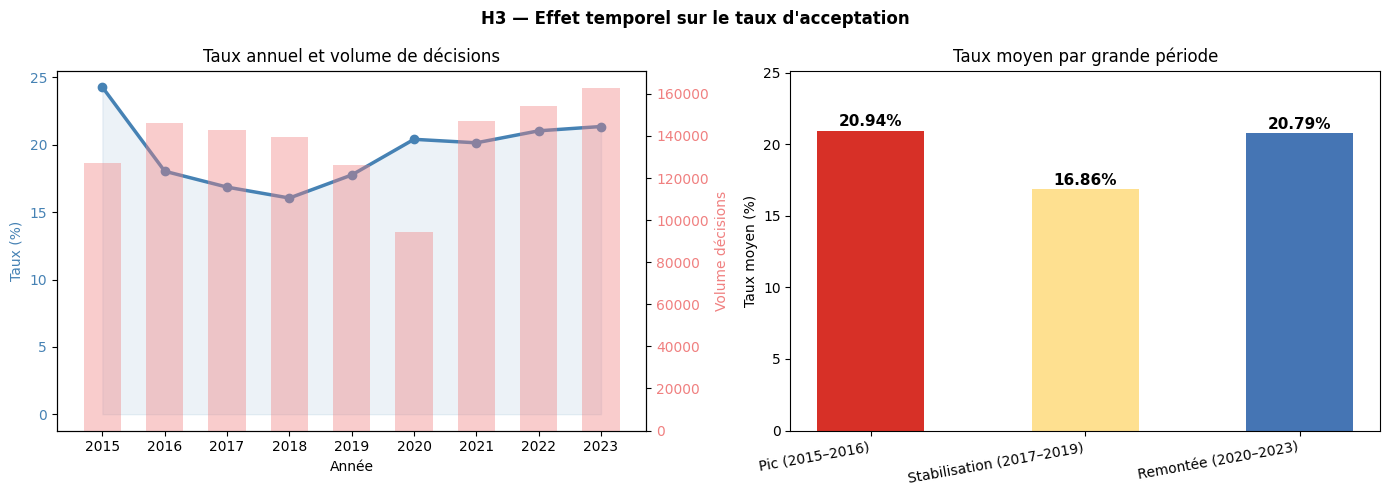

Chute de 6.2 pts entre 2015 (24.3%) et 2016 (18.0%) — pic migratoire
Remontée de 5.3 pts entre 2018 (16.1%) et 2023 (21.4%)
Écart total sur la période : 8.2 points

VERDICT H3 : CONFIRMÉE
Les taux ont clairement chuté pendant le pic migratoire 2015-2016,
puis sont remontés progressivement. L'effet temporel est bien réel.


In [26]:
# Visualisation H3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe temporelle + volume
ax_t = axes[0]
ax_v = ax_t.twinx()
ax_t.plot(h3['annee'], h3['taux'], marker='o', color='steelblue', linewidth=2.5, zorder=5)
ax_t.fill_between(h3['annee'], h3['taux'], alpha=0.1, color='steelblue')
ax_v.bar(h3['annee'], h3['volume'], color='lightcoral', alpha=0.4, width=0.6, zorder=2)
ax_t.set_xlabel('Année')
ax_t.set_ylabel("Taux (%)", color='steelblue')
ax_v.set_ylabel('Volume décisions', color='lightcoral')
ax_t.tick_params(axis='y', labelcolor='steelblue')
ax_v.tick_params(axis='y', labelcolor='lightcoral')
ax_t.set_xticks(h3['annee'])
ax_t.set_title('Taux annuel et volume de décisions')

# Barplot périodes
barres = axes[1].bar(taux_periode['periode'], taux_periode['taux_moyen'],
                     color=['#d73027','#fee090','#4575b4'], width=0.5)
for b, v in zip(barres, taux_periode['taux_moyen']):
    axes[1].text(b.get_x()+b.get_width()/2, v+0.3, f'{v}%', ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylabel("Taux moyen (%)")
axes[1].set_title('Taux moyen par grande période')
axes[1].set_ylim(0, taux_periode['taux_moyen'].max()*1.2)
plt.setp(axes[1].get_xticklabels(), rotation=10, ha='right')

plt.suptitle("H3 — Effet temporel sur le taux d'acceptation", fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/h3_evolution.png', dpi=120)
plt.show()

chute = round(18.04 - 24.28, 1)
remontee = round(21.36 - 16.05, 1)
print(f'Chute de {abs(chute)} pts entre 2015 (24.3%) et 2016 (18.0%) — pic migratoire')
print(f'Remontée de {remontee} pts entre 2018 (16.1%) et 2023 (21.4%)')
print(f'Écart total sur la période : {h3.taux.max()-h3.taux.min():.1f} points')
print()
print('VERDICT H3 : CONFIRMÉE')
print('Les taux ont clairement chuté pendant le pic migratoire 2015-2016,')
print('puis sont remontés progressivement. L\'effet temporel est bien réel.')

### H4 — Facteur économique

In [27]:
# Un point par pays d'accueil : taux moyen vs PIB moyen

h4 = (
    df.groupby('pays_accueil')
    .apply(lambda x: pd.Series({
        'taux': round(x['dec_pos'].sum() / x['dec_total'].sum() * 100, 2),
        'pib':  x['pib_hab'].mean()
    }))
    .reset_index()
)

r4,  p4  = pearsonr(h4['pib'],  h4['taux'])
r4s, p4s = spearmanr(h4['pib'], h4['taux'])
print(f'Pearson  : r = {r4:.3f}   p = {p4:.4f}')
print(f'Spearman : r = {r4s:.3f}   p = {p4s:.4f}')

h4['groupe'] = pd.qcut(h4['pib'], 3, labels=['Faible PIB','PIB moyen','PIB élevé'])
print()
print('Taux moyen par groupe PIB :')
print(h4.groupby('groupe')['taux'].mean().round(1).to_string())

Pearson  : r = 0.754   p = 0.0000
Spearman : r = 0.732   p = 0.0000

Taux moyen par groupe PIB :
groupe
Faible PIB     8.9
PIB moyen     12.5
PIB élevé     40.2


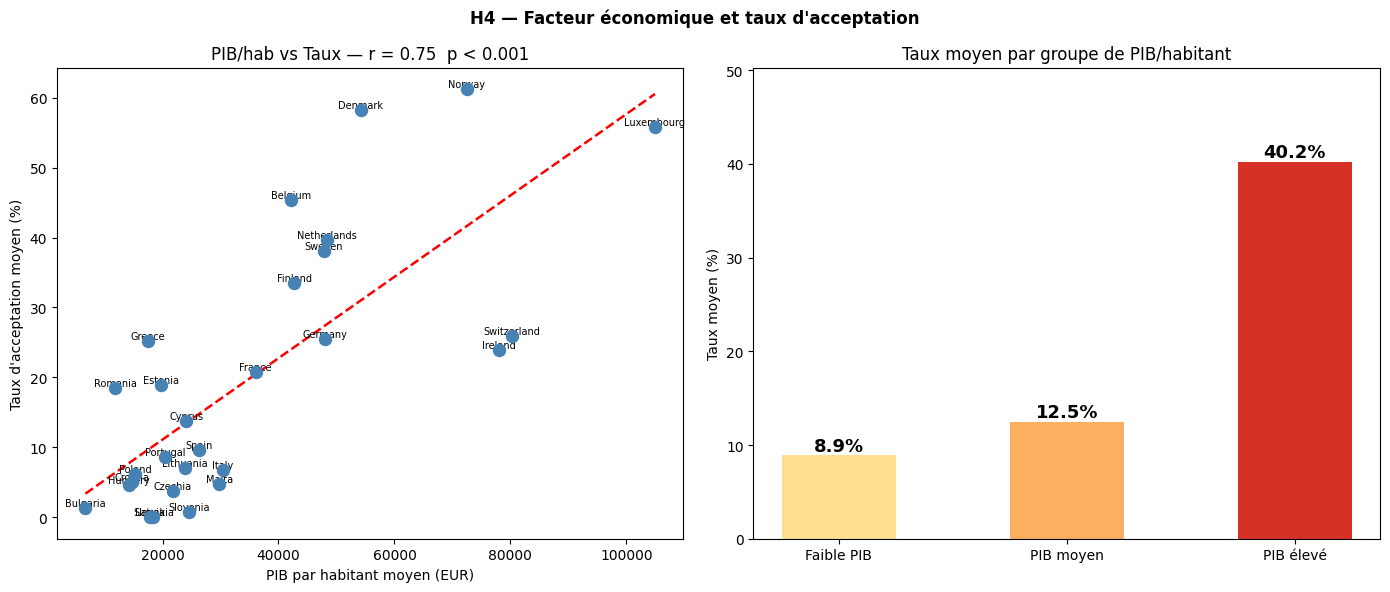

Pearson r = 0.754, Spearman r = 0.732 — les deux sont élevés et p < 0.001
PIB élevé → 40.2%  vs  Faible PIB → 8.9%
Écart : 31.3 points

VERDICT H4 : CONFIRMÉE
Corrélation forte et significative. Les pays riches comme la Norvège (61%),
le Danemark (58%) ou le Luxembourg (56%) acceptent bien plus que les pays
moins riches comme la Lettonie (0%) ou la Hongrie (< 1%).


In [28]:
# Visualisation H4

taux_groupe = h4.groupby('groupe')['taux'].mean().round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter PIB vs taux
axes[0].scatter(h4['pib'], h4['taux'], color='steelblue', s=75, zorder=5)
for _, row in h4.iterrows():
    axes[0].annotate(row['pays_accueil'], (row['pib'], row['taux']),
                     fontsize=7, ha='center', va='bottom')
z = np.polyfit(h4['pib'], h4['taux'], 1)
x_r = np.linspace(h4['pib'].min(), h4['pib'].max(), 100)
axes[0].plot(x_r, np.poly1d(z)(x_r), 'r--', linewidth=1.8)
axes[0].set_xlabel('PIB par habitant moyen (EUR)')
axes[0].set_ylabel("Taux d'acceptation moyen (%)")
axes[0].set_title(f'PIB/hab vs Taux — r = {r4:.2f}  p < 0.001')

# Barplot par groupe
barres = axes[1].bar(taux_groupe.index, taux_groupe.values,
                     color=['#fee090','#fdae61','#d73027'], width=0.5)
for b, v in zip(barres, taux_groupe.values):
    axes[1].text(b.get_x()+b.get_width()/2, v+0.5, f'{v}%',
                 ha='center', fontsize=13, fontweight='bold')
axes[1].set_ylabel("Taux moyen (%)")
axes[1].set_title('Taux moyen par groupe de PIB/habitant')
axes[1].set_ylim(0, taux_groupe.max()*1.25)

plt.suptitle("H4 — Facteur économique et taux d'acceptation", fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/h4_pib_taux.png', dpi=120)
plt.show()

print(f'Pearson r = {r4:.3f}, Spearman r = {r4s:.3f} — les deux sont élevés et p < 0.001')
print(f"PIB élevé → {taux_groupe['PIB élevé']}%  vs  Faible PIB → {taux_groupe['Faible PIB']}%")
print(f"Écart : {taux_groupe['PIB élevé'] - taux_groupe['Faible PIB']:.1f} points")
print()
print('VERDICT H4 : CONFIRMÉE')
print('Corrélation forte et significative. Les pays riches comme la Norvège (61%),')
print('le Danemark (58%) ou le Luxembourg (56%) acceptent bien plus que les pays')
print('moins riches comme la Lettonie (0%) ou la Hongrie (< 1%).')

---
## 11. Synthèse des hypothèses

In [29]:
synthese = pd.DataFrame([
    ['H1', 'Volume élevé → taux plus faible',
     f'r = {r1:.3f}  (p = {p1:.3f})', '❌ INFIRMÉE',
     'Aucune relation entre volume et taux'],
    ['H2', 'Pays en crise → taux plus élevé',
     f'r = {r2:.3f}  (p = {p2:.3f})', '⚠️ PARTIELLE',
     'Vraie qualitativement, non prouvée stat. (EM-DAT ≠ conflits)'],
    ['H3', 'Taux varient selon les périodes',
     'Écart 8.2 pts (2015–2023)', '✅ CONFIRMÉE',
     'Chute au pic migratoire, remontée progressive'],
    ['H4', 'PIB élevé → taux plus élevé',
     f'r = {r4:.3f}  (p < 0.001)', '✅ CONFIRMÉE',
     'Résultat le plus solide — 40.2% vs 8.9%'],
], columns=['H', 'Énoncé', 'Statistique', 'Verdict', 'Commentaire'])

print('SYNTHÈSE')
print('='*105)
print(synthese.to_string(index=False))
print('='*105)

SYNTHÈSE
 H                          Énoncé               Statistique      Verdict                                                  Commentaire
H1 Volume élevé → taux plus faible    r = 0.022  (p = 0.739)   ❌ INFIRMÉE                         Aucune relation entre volume et taux
H2 Pays en crise → taux plus élevé   r = -0.016  (p = 0.731) ⚠️ PARTIELLE Vraie qualitativement, non prouvée stat. (EM-DAT ≠ conflits)
H3 Taux varient selon les périodes Écart 8.2 pts (2015–2023)  ✅ CONFIRMÉE                Chute au pic migratoire, remontée progressive
H4     PIB élevé → taux plus élevé    r = 0.754  (p < 0.001)  ✅ CONFIRMÉE                      Résultat le plus solide — 40.2% vs 8.9%


---
## 12. Conclusions

### Rappel de la problématique

**Pourquoi les taux d'acceptation des demandes d'asile africaines varient-ils entre les pays européens ?**

L'analyse couvre 4 867 combinaisons pays d'accueil × pays d'origine entre 2015 et 2023, soit 1 239 953 décisions de première instance.

Le taux moyen est de **19,5 %**, mais il va de **0 %** (Lettonie) à **61,2 %** (Norvège).

---

### Réponse aux hypothèses

**H1 — Infirmée** : le volume de demandes reçues n'a aucun effet mesurable sur le taux (r = 0.022). La France, premier pays de destination africaine, affiche un taux stable autour de 20 % quelle que soit la pression reçue.

**H2 — Partiellement confirmée** : les pays les plus touchés par des crises obtiennent des taux plus élevés (Érythrée 66,8 %, Soudan 41,3 %, Somalie 32,2 %), mais la corrélation statistique avec EM-DAT est quasi nulle. EM-DAT ne recense pas les conflits armés, qui sont pourtant la principale raison de fuite.

**H3 — Confirmée** : chute de 6,2 points entre 2015 et 2016 (pic migratoire), puis remontée de 5,3 points jusqu'en 2023. Les périodes de forte pression ont bien influencé les taux.

**H4 — Confirmée** : c'est le facteur le plus déterminant (r = 0.754, p < 0.001). Les pays à PIB élevé acceptent en moyenne 40,2 % des demandes contre 8,9 % pour les pays à faible PIB.

### Conclusion générale

Les disparités entre pays s'expliquent principalement par le **niveau économique du pays d'accueil** et les **effets des crises migratoires sur les politiques nationales**. Le volume de demandes reçues n'a aucun impact.

### Limites

- EM-DAT ne couvre pas les conflits armés → H2 sous-estimée
- Analyse limitée à la première instance
- Corrélation ≠ causalité

### Pistes d'amélioration

- Intégrer les données ACLED (conflits armés) pour mieux tester H2
- Ajouter un indice de politique migratoire (MIPEX) par pays
- Réaliser une régression multiple pour quantifier la part de chaque facteur